# Load data

In [88]:
# Imports
import numpy as np
import BLEanalysis.angleinference as AngleInference
np.set_printoptions(precision=2,suppress=True)
import matplotlib.pyplot as plt
from BLEanalysis.signals import Signals
from BLEanalysis.angleinference import AnglesUsePatternMeans, normalise_logs_to_ps, AnglesUsePeaks, AnglesUseRejectionSampling
from scipy.stats import circmean
import pandas as pd
import matplotlib as mpl

In [89]:
# Training data used for angle inference, consists of reading many packets over many rotations of the transmitter at a different
# location to that of the test data. This file was taken at Ponderosa Park, Sheffield, UK
trainingsigs = Signals("../bluetooth_experiments/no rf amp experiments/noamploc2long.log", ['d'], angleOffset = 38)
    
# Helper function to subsample randomly from a set of signal strengths
def randomSampleFromBurstDict(dict, n):
    samples = {}
    samples['transmitter_position'] = dict['transmitter_position']
    samples['rssis'] = []
    samples['angles'] = []
    samples['times'] = []

    if n >= len(dict['rssis']):
        return dict
    
    #rand_indices = np.random.choice(len(dict['rssis']), size=n, replace=False)
    rand_indices = np.linspace(0, len(dict['rssis'])-1, n)
    rand_indices = [int(x) for x in rand_indices]
    
    # We rotate these indecies so we don't always hit near the peak for some particular n of samples
    rotationValue = np.random.randint(0, len(dict['rssis']))
    rand_indices = np.array(rand_indices)
    rand_indices = (rand_indices + rotationValue) % len(dict['rssis'])
    
    #print(rotationValue)
    # Collect samples at those indices
    samples['rssis'] = np.array([dict['rssis'][i] for i in rand_indices])
    samples['angles'] = np.array([dict['angles'][i] for i in rand_indices])
    samples['times'] = np.array([dict['times'][i] for i in rand_indices])

    return samples

# Helper function to calculate error between two angles
def angularDistance(a1, a2):
    diff = abs(a1 - a2) % 360
    return np.abs(min(diff, 360 - diff))

Standardising angles and times (shifting by 38.00 degrees)


Standardising angles and times (shifting by 90.00 degrees)
Transmitter       Number of records
        c                 8315


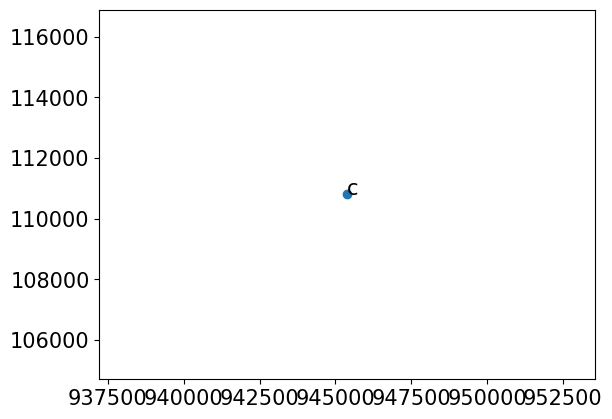

In [90]:
# Load in test data, measured at Common Lane Open Space, Sheffield, UK
testsigs = Signals("../bluetooth_experiments/March 26 2025 Field Trial/Range Trials/1.log",['c'],angleOffset= 90)
testsigs.configureTransmitter('c',0,0,1,1)
testsigs.noramliseTransmitterLocs()
testsigs.summarise(showNormalised = False)

Our data looks like this:

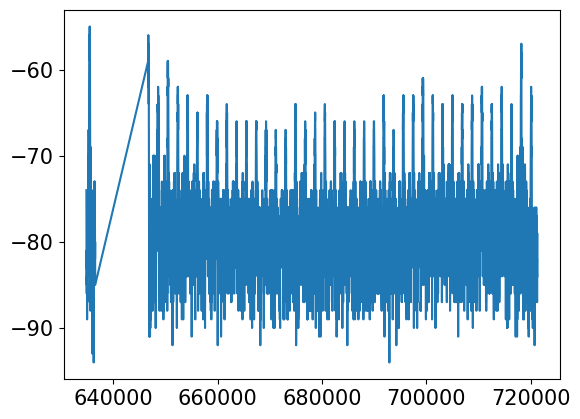

In [91]:
plt.plot([i[3] for i in testsigs.data],[i[0] for i in testsigs.data])
plt.show()

Cut off the first and last bursts as they were taken when we were setting up and turning off the reciever, therefore were subject to additional obstructions

In [92]:
testsigs.data = testsigs.data[250:len(testsigs.data)-40]
#for x in testsigs.data:
#    x[3] *= 10

Since we can't exactly know what true angle the reciever was located at from the transmitter in the test data due to human error of where we placed the reciever (in this test, aimed to be at 0 degrees), we will instead use the average of the angles in the packets with peak RSSIs of every transmitter rotation that was meausred.

In [93]:
burst, time = testsigs.parseBursts(burstInterval=0, offset = 0)
peaks = []
for b in burst:
    maxind = np.argmax(b['rssis'])
    peaks.append(b['angles'][maxind])

groundTruthAngle = 360 - np.rad2deg(circmean(peaks)) % 360
print("True angle = " + str(groundTruthAngle))

True angle = 266.9461548619557


# Inference Example

Choose a burst scan:

In [123]:
burstIndex = 10
nSamps = 15
currentBurst = randomSampleFromBurstDict(burst[burstIndex], nSamps)


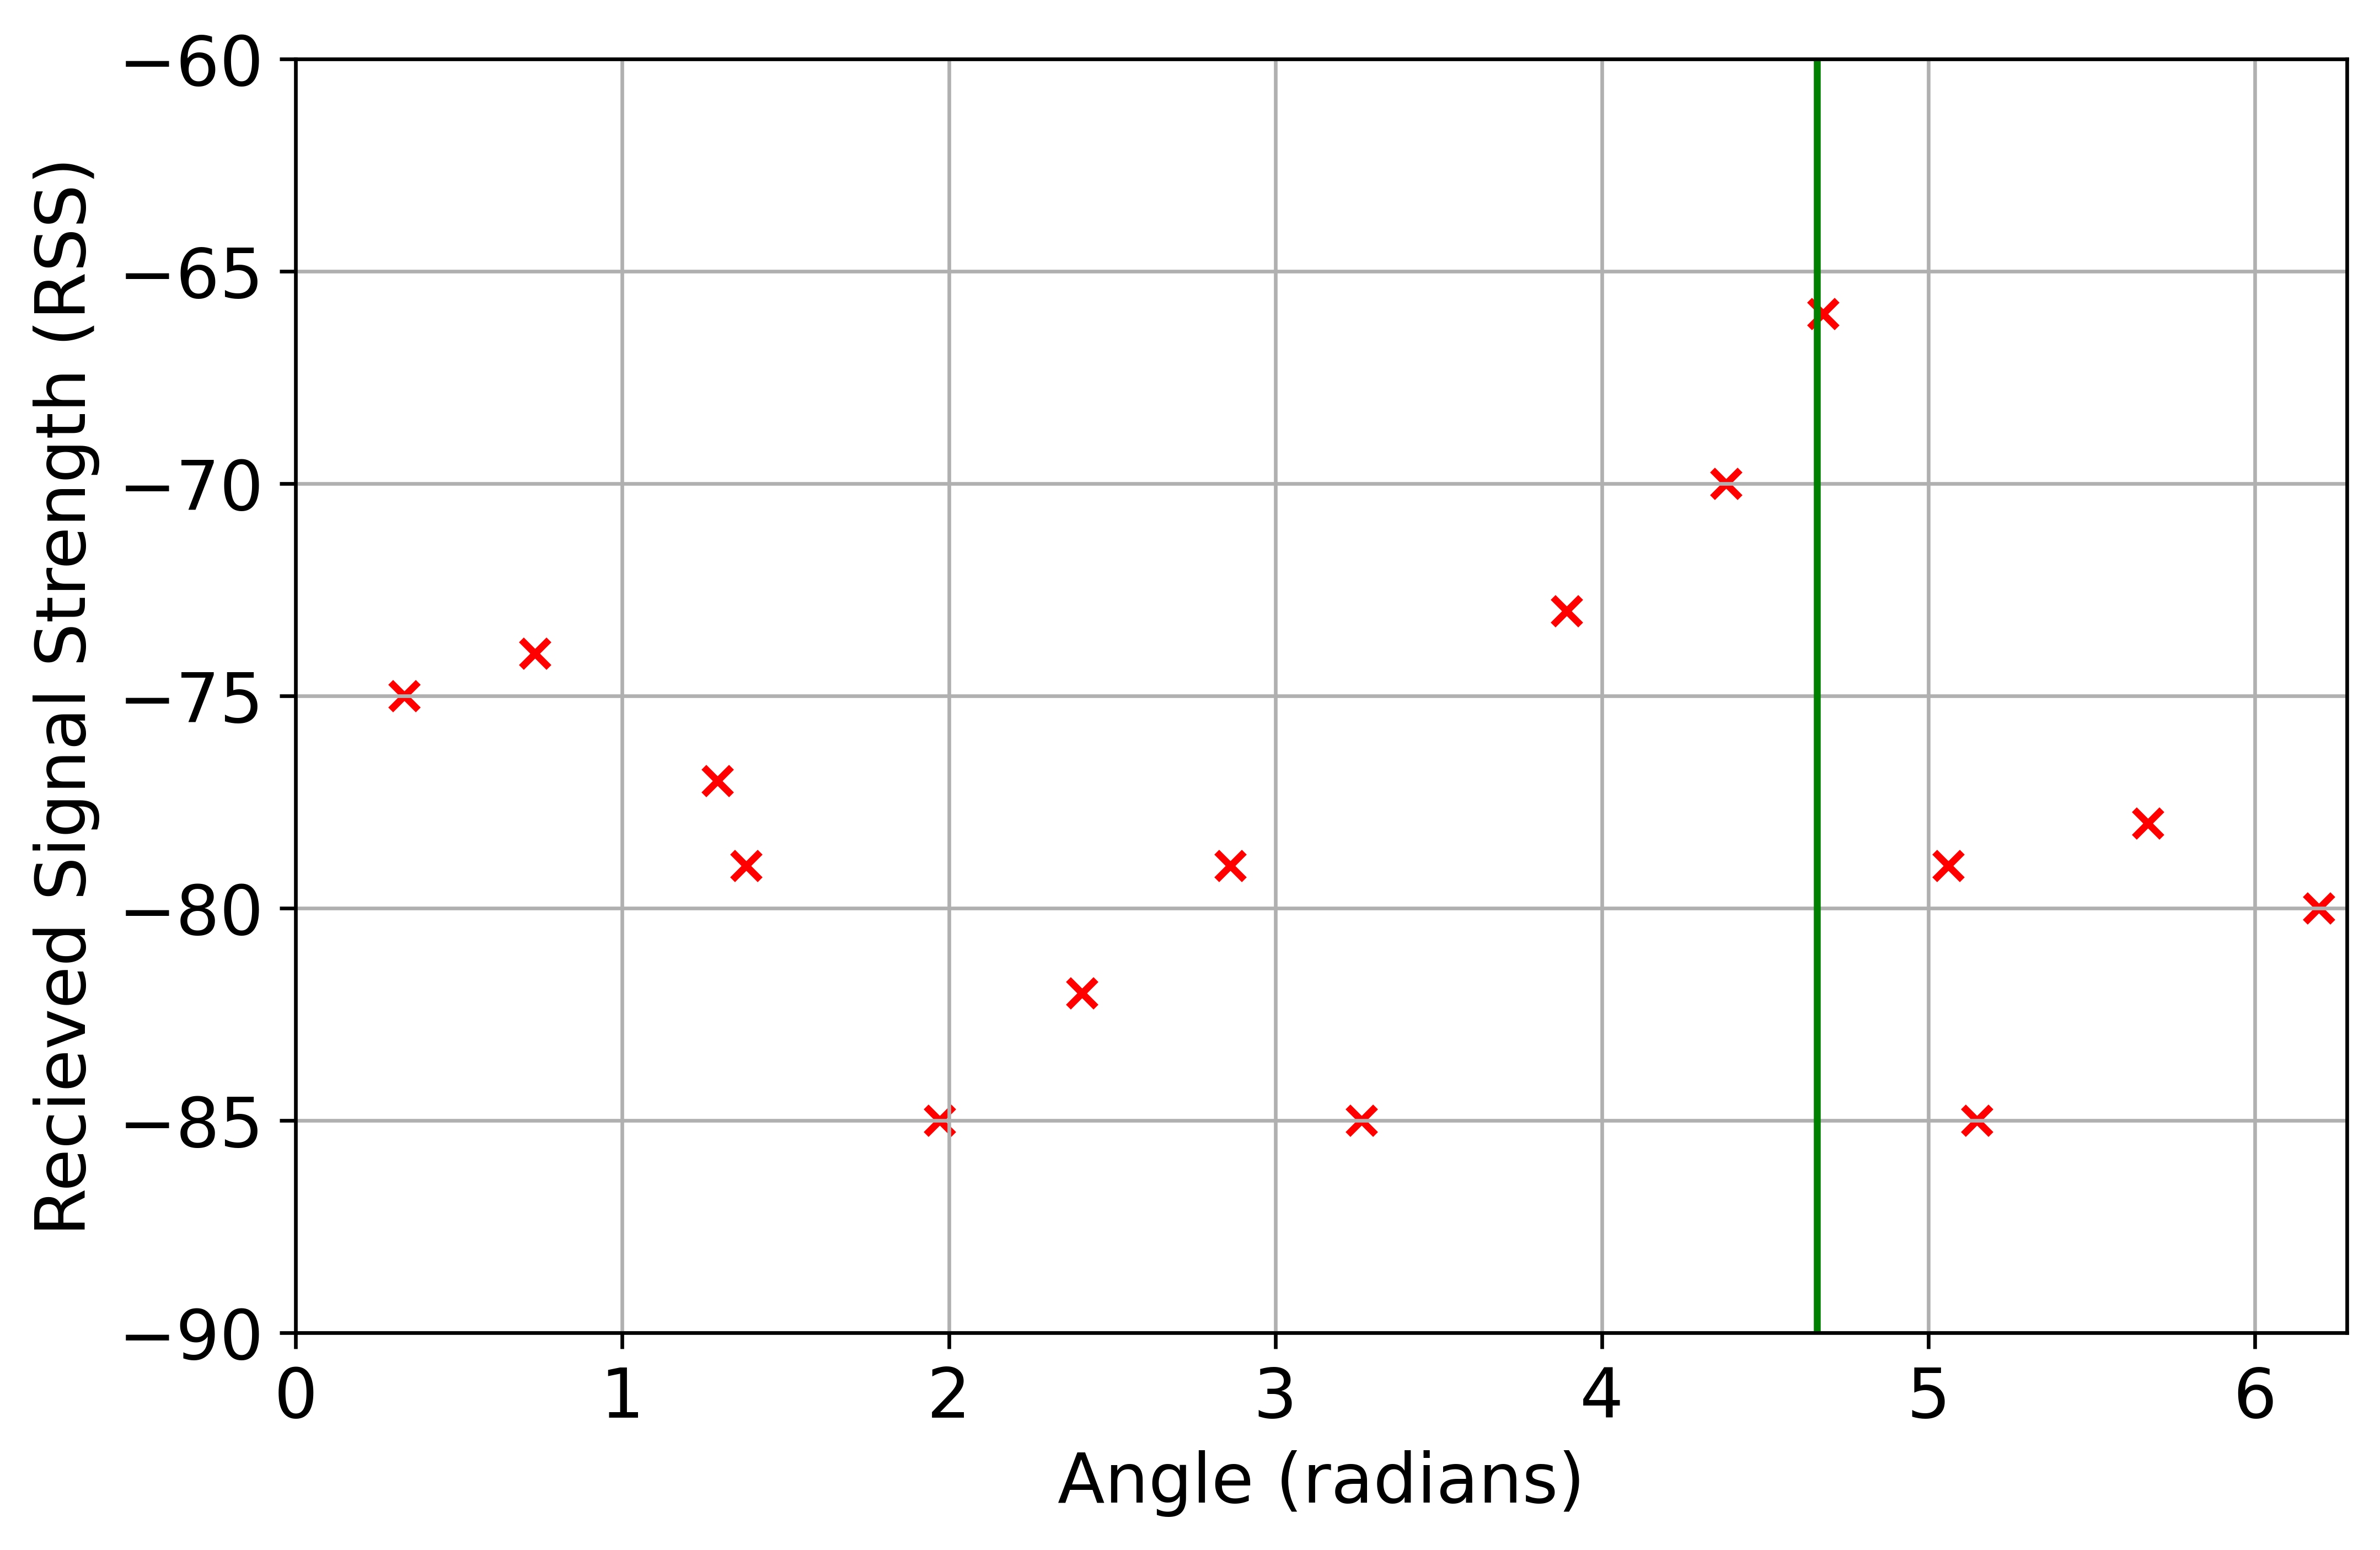

In [124]:
# THIS PLOT SHOWS PACKETS AS THEY ARE, NOT ADJUSTED FOR BEING COUNTERCLOCKWISE
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 15}

mpl.rc('font', **font)
fig, ax1 = plt.subplots(figsize=(8, 5), dpi = 600)
burst, time = testsigs.parseBursts(burstInterval=0, offset = 0)
plt.scatter( (-(currentBurst['angles'])) % (2 * np.pi), currentBurst['rssis'], marker = 'x', color = 'r')

plt.xlim(0,np.pi*2)
plt.ylim(-90,-60)
plt.axvline(x = np.deg2rad(groundTruthAngle), color = 'g')
plt.ylabel("Recieved Signal Strength (RSS)")
plt.xlabel("Angle (radians)")
plt.grid()

Probability via pattern matching:

Standardising angles and times (shifting by 38.00 degrees)
Highest density at angle: 265
NLPD2.3726720972468582


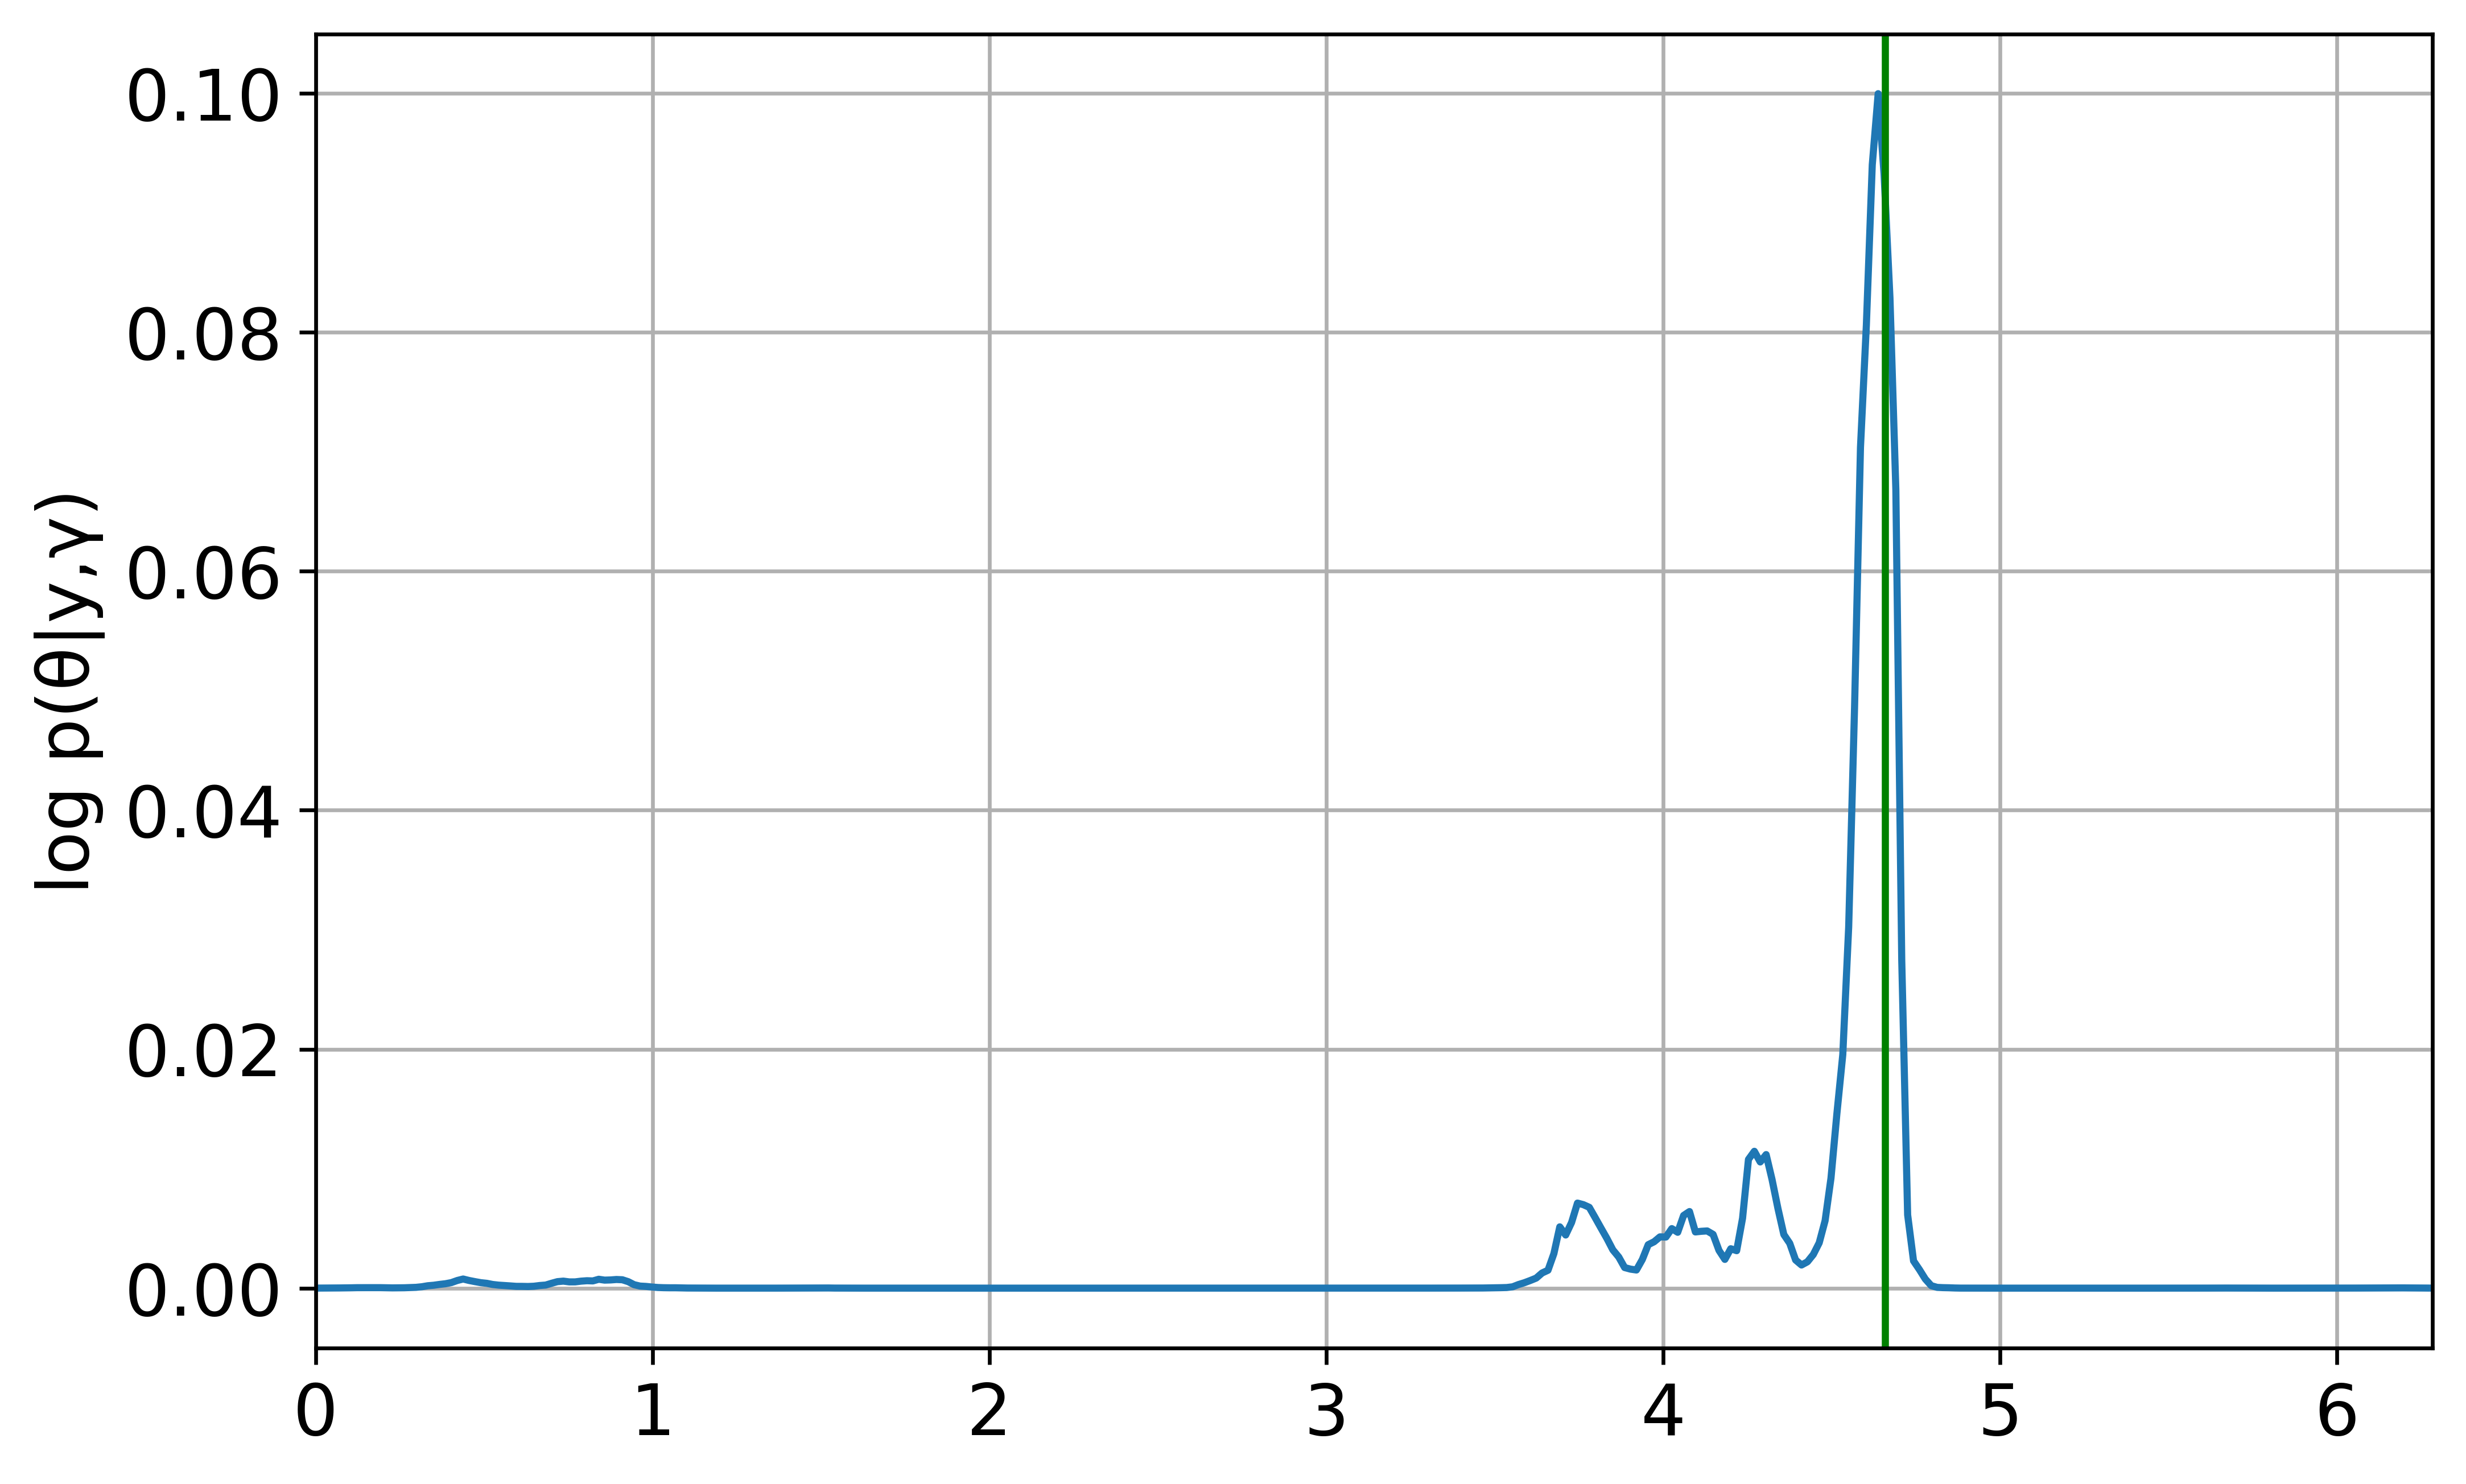

In [125]:
import scipy
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 15}

mpl.rc('font', **font)
fig, ax1 = plt.subplots(figsize=(8, 5), dpi = 600)
angles = AnglesUsePatternMeans(noisevar=9**2)

logps,_,_,_ = angles.infer(currentBurst['rssis'],currentBurst['angles'])
#logps = np.log(np.exp(logps)+1e-1000)
ps = normalise_logs_to_ps(logps)
plt.plot(np.linspace(0,np.pi*2,360),ps)
#print(np.max(logps),np.max(ps),np.sum(ps))
        
#plt.ylim([-0.001,1]) #1.1*np.max(ps)])
plt.grid()
#plt.ylim(0,0.25)
plt.xlim(0,np.pi*2)
plt.ylabel("log p(θ|y,γ)")
plt.axvline(x = np.deg2rad(groundTruthAngle), color = 'g')

print("Highest density at angle: " + str(np.argmax(ps)))
print("NLPD" + str(-np.log(ps[groundTruthAngle.astype(int)])))

Smoothing and peak finding:

In [103]:
angles = AnglesUsePeaks(windowLength = 3 )
prediction = angles.infer(currentBurst['rssis'],currentBurst['angles'])
print(np.rad2deg(prediction))

282.0


/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


# Tabulated comparison

Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)


/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/newEnv/lib/python3.12/site-packages/BLEanalysis/angleinference.py:228: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return(np.rad2deg(circmean(predangle)))


Finished testing 3 samples.
Finished testing 4 samples.
Finished testing 5 samples.
Finished testing 6 samples.
Finished testing 7 samples.
Finished testing 8 samples.
Finished testing 9 samples.
Finished testing 10 samples.
Finished testing 15 samples.
Finished testing 20 samples.
Finished testing 25 samples.
Finished testing 30 samples.
Finished testing 40 samples.
Finished testing 50 samples.
Finished testing 100 samples.


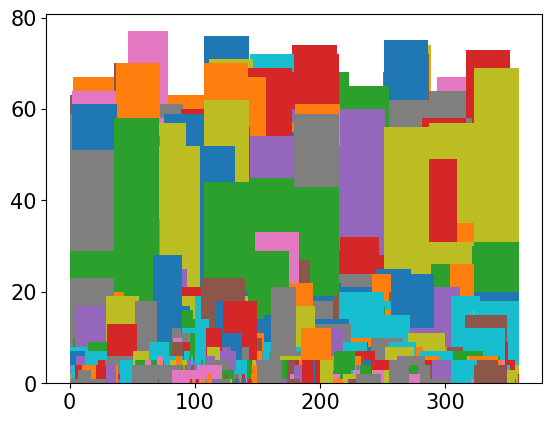

In [9]:
# Load data and define tests to perform
burst, time = testsigs.parseBursts(burstInterval=0, offset = 0)
nSamps = [3,4,5,6,7,8,9,10,15,20,25,30,40,50,100]
nTests = 1000
rejectionSampResults = []
peakFindingResults= []
fullProbDistResults = []
anglesPattern = AnglesUsePatternMeans(noisevar=3**2)
anglesPeak = AnglesUsePeaks(windowLength = 3)
rejectionSamp = AnglesUseRejectionSampling(rejectionTableStep = 100)

# For each specified number of samples
for x, n in enumerate(nSamps):
    current_rejectionSampResults = []
    current_peakFindingResults= []
    current_fullProbDistResults = []
    # Repeat test nTests times
    for i in range(nTests):
        # Select burst and randomly sample from it
        burstIndex = np.random.randint(0, len(burst)-1)
        currentBurst = randomSampleFromBurstDict(burst[burstIndex], n)

        # Get prediction from probability distribution
        logps,_,_,_ = anglesPattern.infer(currentBurst['rssis'],currentBurst['angles'])
        ps = normalise_logs_to_ps(logps)
        current_fullProbDistResults.append(angularDistance(groundTruthAngle, np.argmax(ps)))

        # Get prediction from peak finding heuristic
        prediction = anglesPeak.infer(currentBurst['rssis'],currentBurst['angles'])
        current_peakFindingResults.append(angularDistance(groundTruthAngle, np.rad2deg(prediction)))

        # Get prediction from rejection sampling 
        rt = 1
        prediction = np.nan
        while np.isnan(prediction) == True:
            prediction = rejectionSamp.infer(currentBurst, rejectionThreshold = rt)
            rt = rt + 1
        if np.isnan(prediction) == False:
            current_rejectionSampResults.append(angularDistance(groundTruthAngle,prediction))
    print("Finished testing " +str(n) + " samples.")
    rejectionSampResults.append(current_rejectionSampResults)
    peakFindingResults.append(current_peakFindingResults)
    fullProbDistResults.append(current_fullProbDistResults)

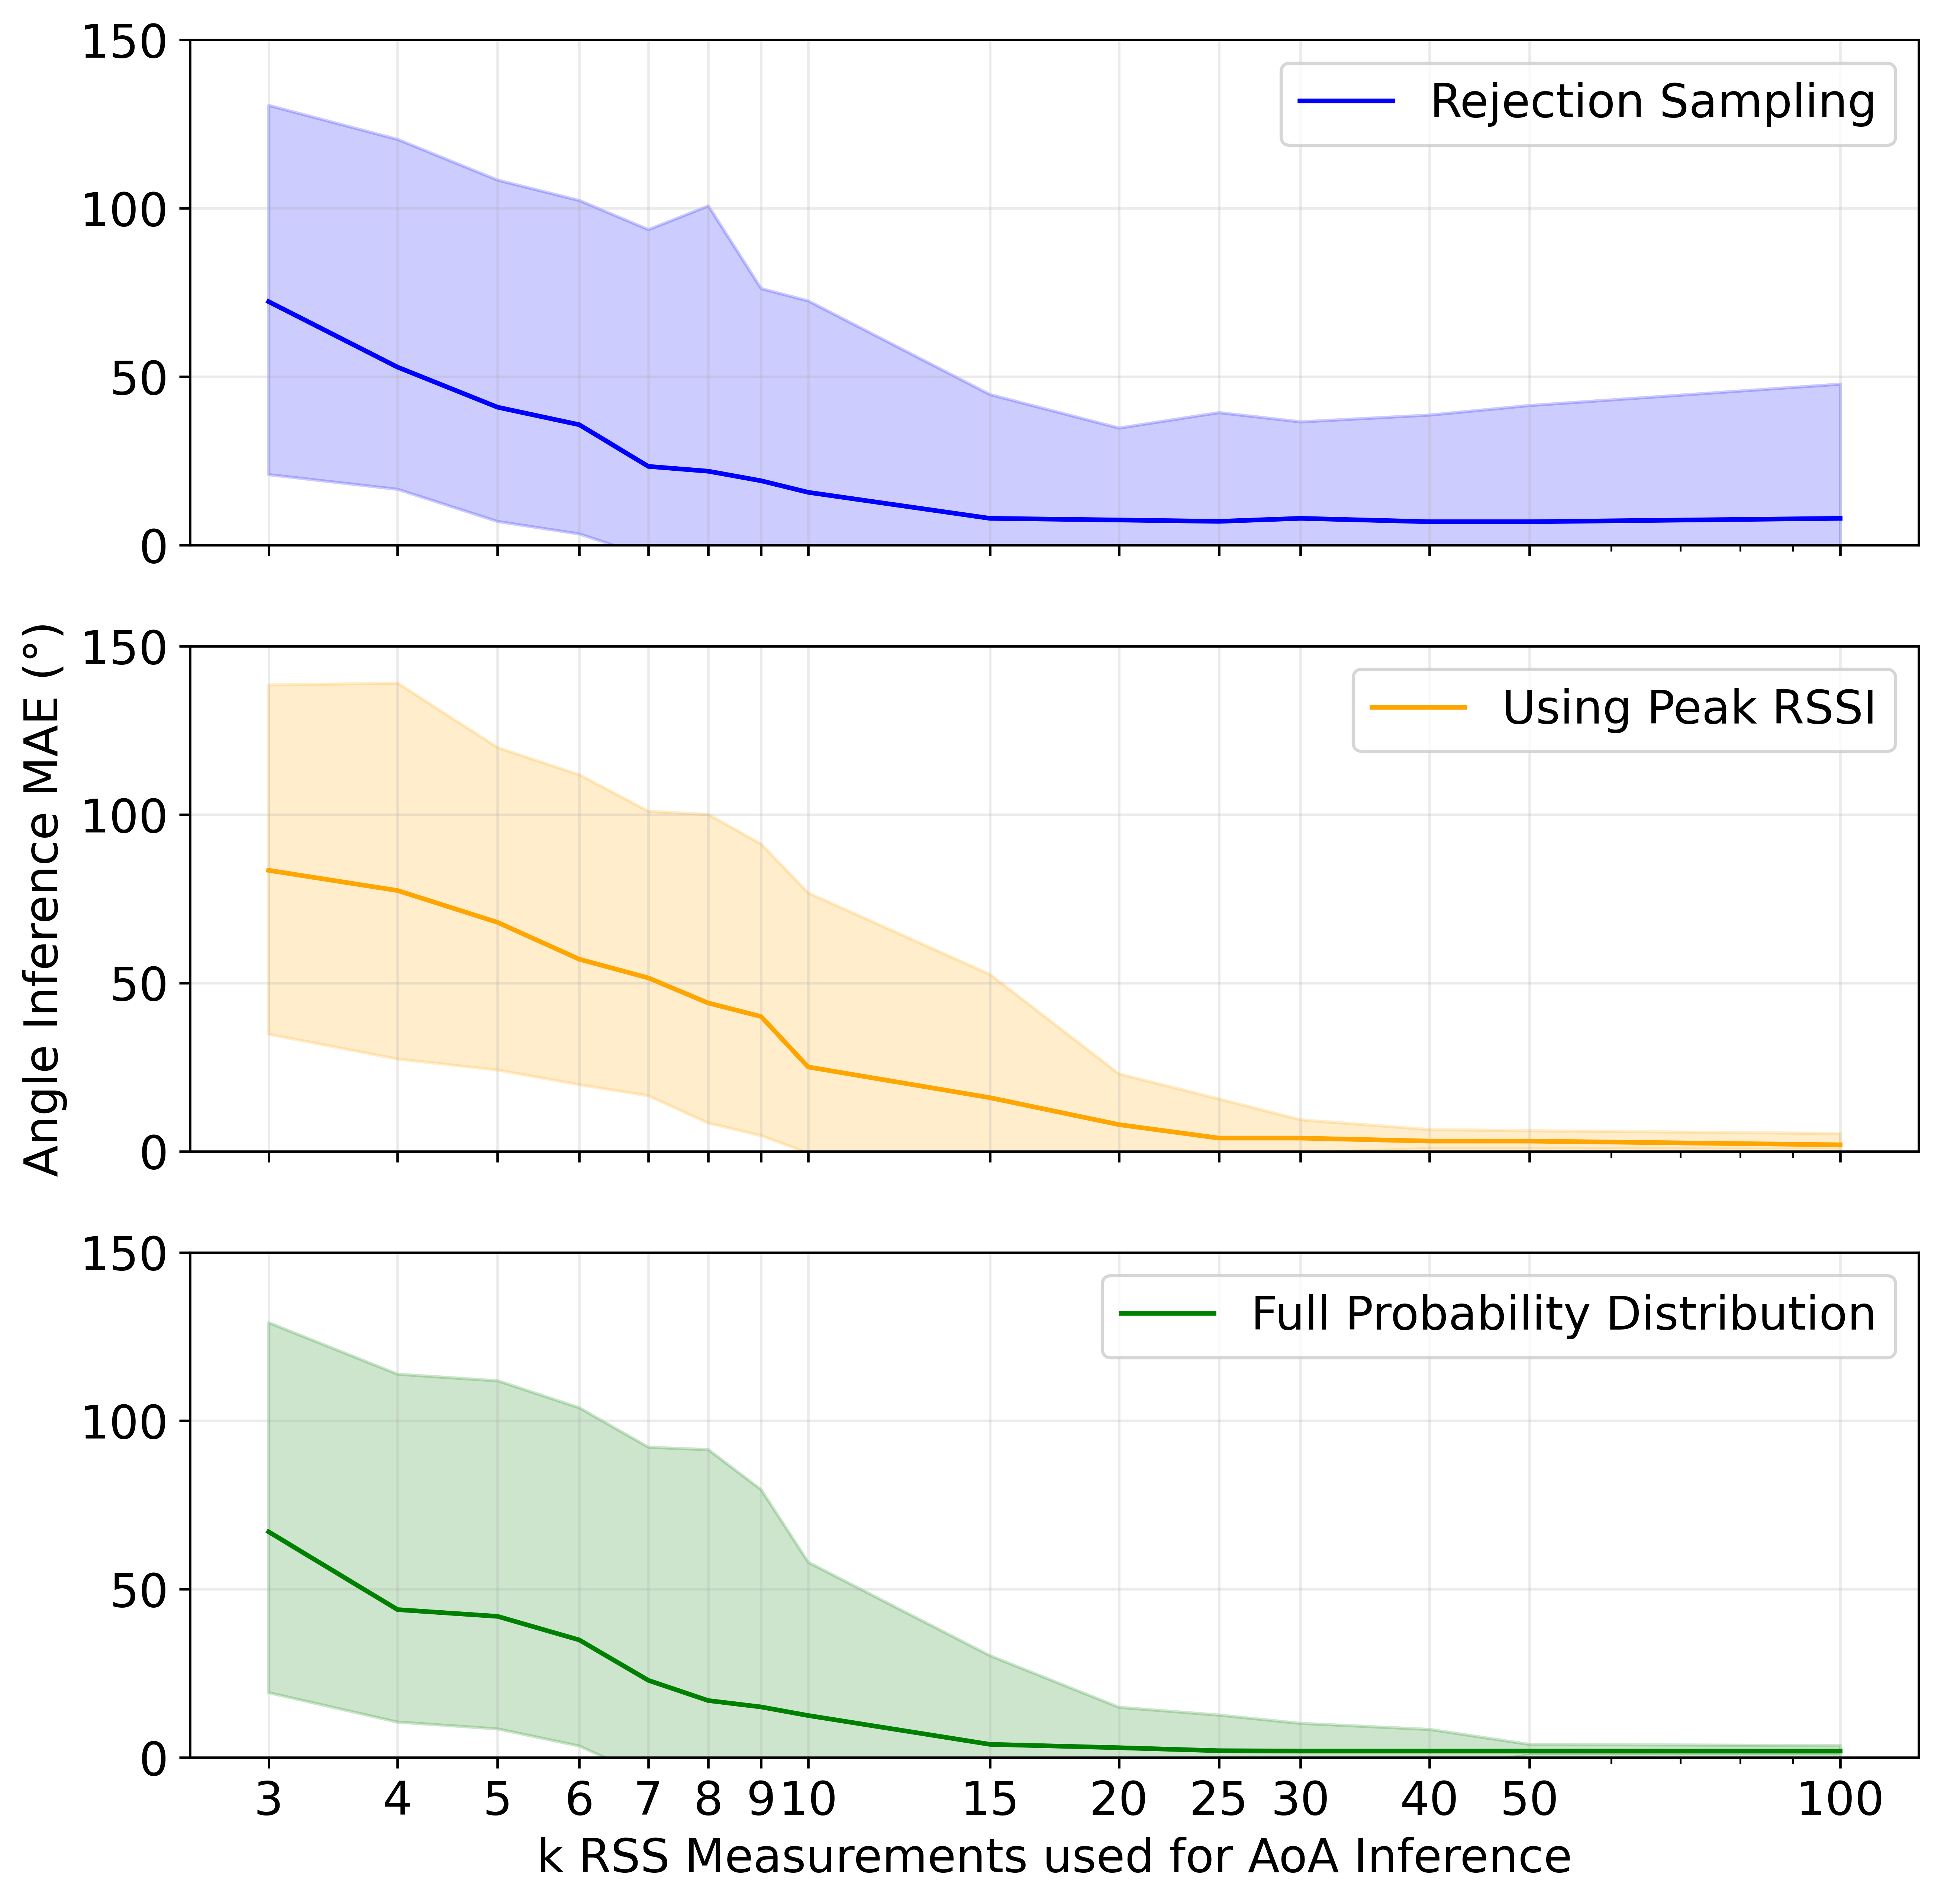

In [10]:
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 15}

mpl.rc('font', **font)
fig, ax1 = plt.subplots(3,1,figsize=(10,10), sharex=True, sharey=True,dpi=600)
ax1[0].plot(nSamps,[np.median(x) for x in rejectionSampResults], label = "Rejection Sampling", color="blue")
ax1[0].fill_between(
    nSamps,
    [m + s for m, s in zip([np.mean(x) for x in rejectionSampResults], [np.std(x) for x in rejectionSampResults])],
    [m - s for m, s in zip([np.mean(x) for x in rejectionSampResults], [np.std(x) for x in rejectionSampResults])],
    color="blue",
    alpha=0.2,
)
ax1[1].plot(nSamps,[np.median(x) for x in peakFindingResults], label = "Using Peak RSSI",color="orange")
ax1[1].fill_between(
    nSamps,
    [m + s for m, s in zip([np.mean(x) for x in peakFindingResults], [np.std(x) for x in peakFindingResults])],
    [m - s for m, s in zip([np.mean(x) for x in peakFindingResults], [np.std(x) for x in peakFindingResults])],
    color="orange",
    alpha=0.2,
)
ax1[2].plot(nSamps,[np.median(x) for x in fullProbDistResults], label = "Full Probability Distribution",color="green")
ax1[2].fill_between(
    nSamps,
    [m + s for m, s in zip([np.mean(x) for x in fullProbDistResults], [np.std(x) for x in fullProbDistResults])],
    [m - s for m, s in zip([np.mean(x) for x in fullProbDistResults], [np.std(x) for x in fullProbDistResults])],
    color="green",
    alpha=0.2,
)
ax1[1].set_ylabel("Angle Inference MAE (°)")
ax1[0].legend()
ax1[1].legend()
ax1[2].legend()
plt.xlabel("k RSS Measurements used for AoA Inference")
plt.ylim(0,150)
plt.xscale("log")
plt.xticks(nSamps, [str(t) for t in nSamps])
ax1[0].grid(alpha=0.25)
ax1[1].grid(alpha=0.25)
ax1[2].grid(alpha=0.25)

# Confidence of Angle Prediction vs Accuracy

Here I select a burst scan, vary the number k RSSI measurements within, and for each k I plot the MAE of angle prediction (argmax of the pd) against the confidence of the inferred proability density. This shows if the confidence of the pd gives any meaningful information about the true angle.

In [43]:
import scipy
burstIndex = 10
k = [3,5,10,15,20,25,30,40,50,75,100,200]
angles = AnglesUsePatternMeans(noisevar=20**2)
accuracies = []
variances = []
nTests = 1000

for samps in k:
    currentvar = []
    currentacc = []
    for x in range(nTests):
        burst, time = testsigs.parseBursts(burstInterval=0, offset = 0)
        currentBurst = randomSampleFromBurstDict(burst[burstIndex], samps)

        logps,_,_,_ = angles.infer(currentBurst['rssis'],currentBurst['angles'])
        ps = normalise_logs_to_ps(logps)
        # NLPD
        currentacc.append(-np.log(ps[groundTruthAngle.astype(int)])) #angularDistance(groundTruthAngle, np.argmax(ps)))
        # Entropy
        currentvar.append(scipy.stats.entropy(ps))
        #a = np.linspace(0,np.pi*2,360)
        #currentvar.append(np.sum(np.cos(a)*
    accuracies.append(np.mean(currentacc))
    variances.append(np.mean(currentvar))

Standardising angles and times (shifting by 38.00 degrees)


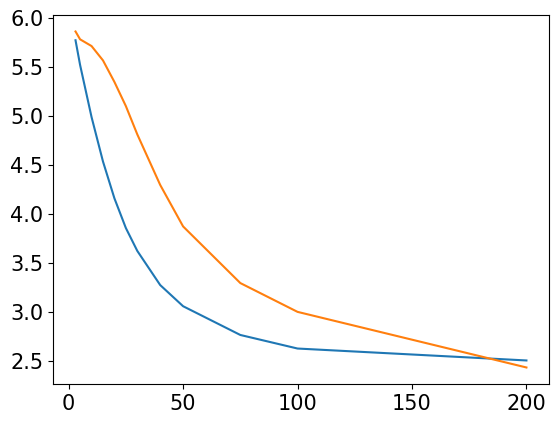

In [44]:
plt.plot(k, accuracies)
plt.plot(k, variances)

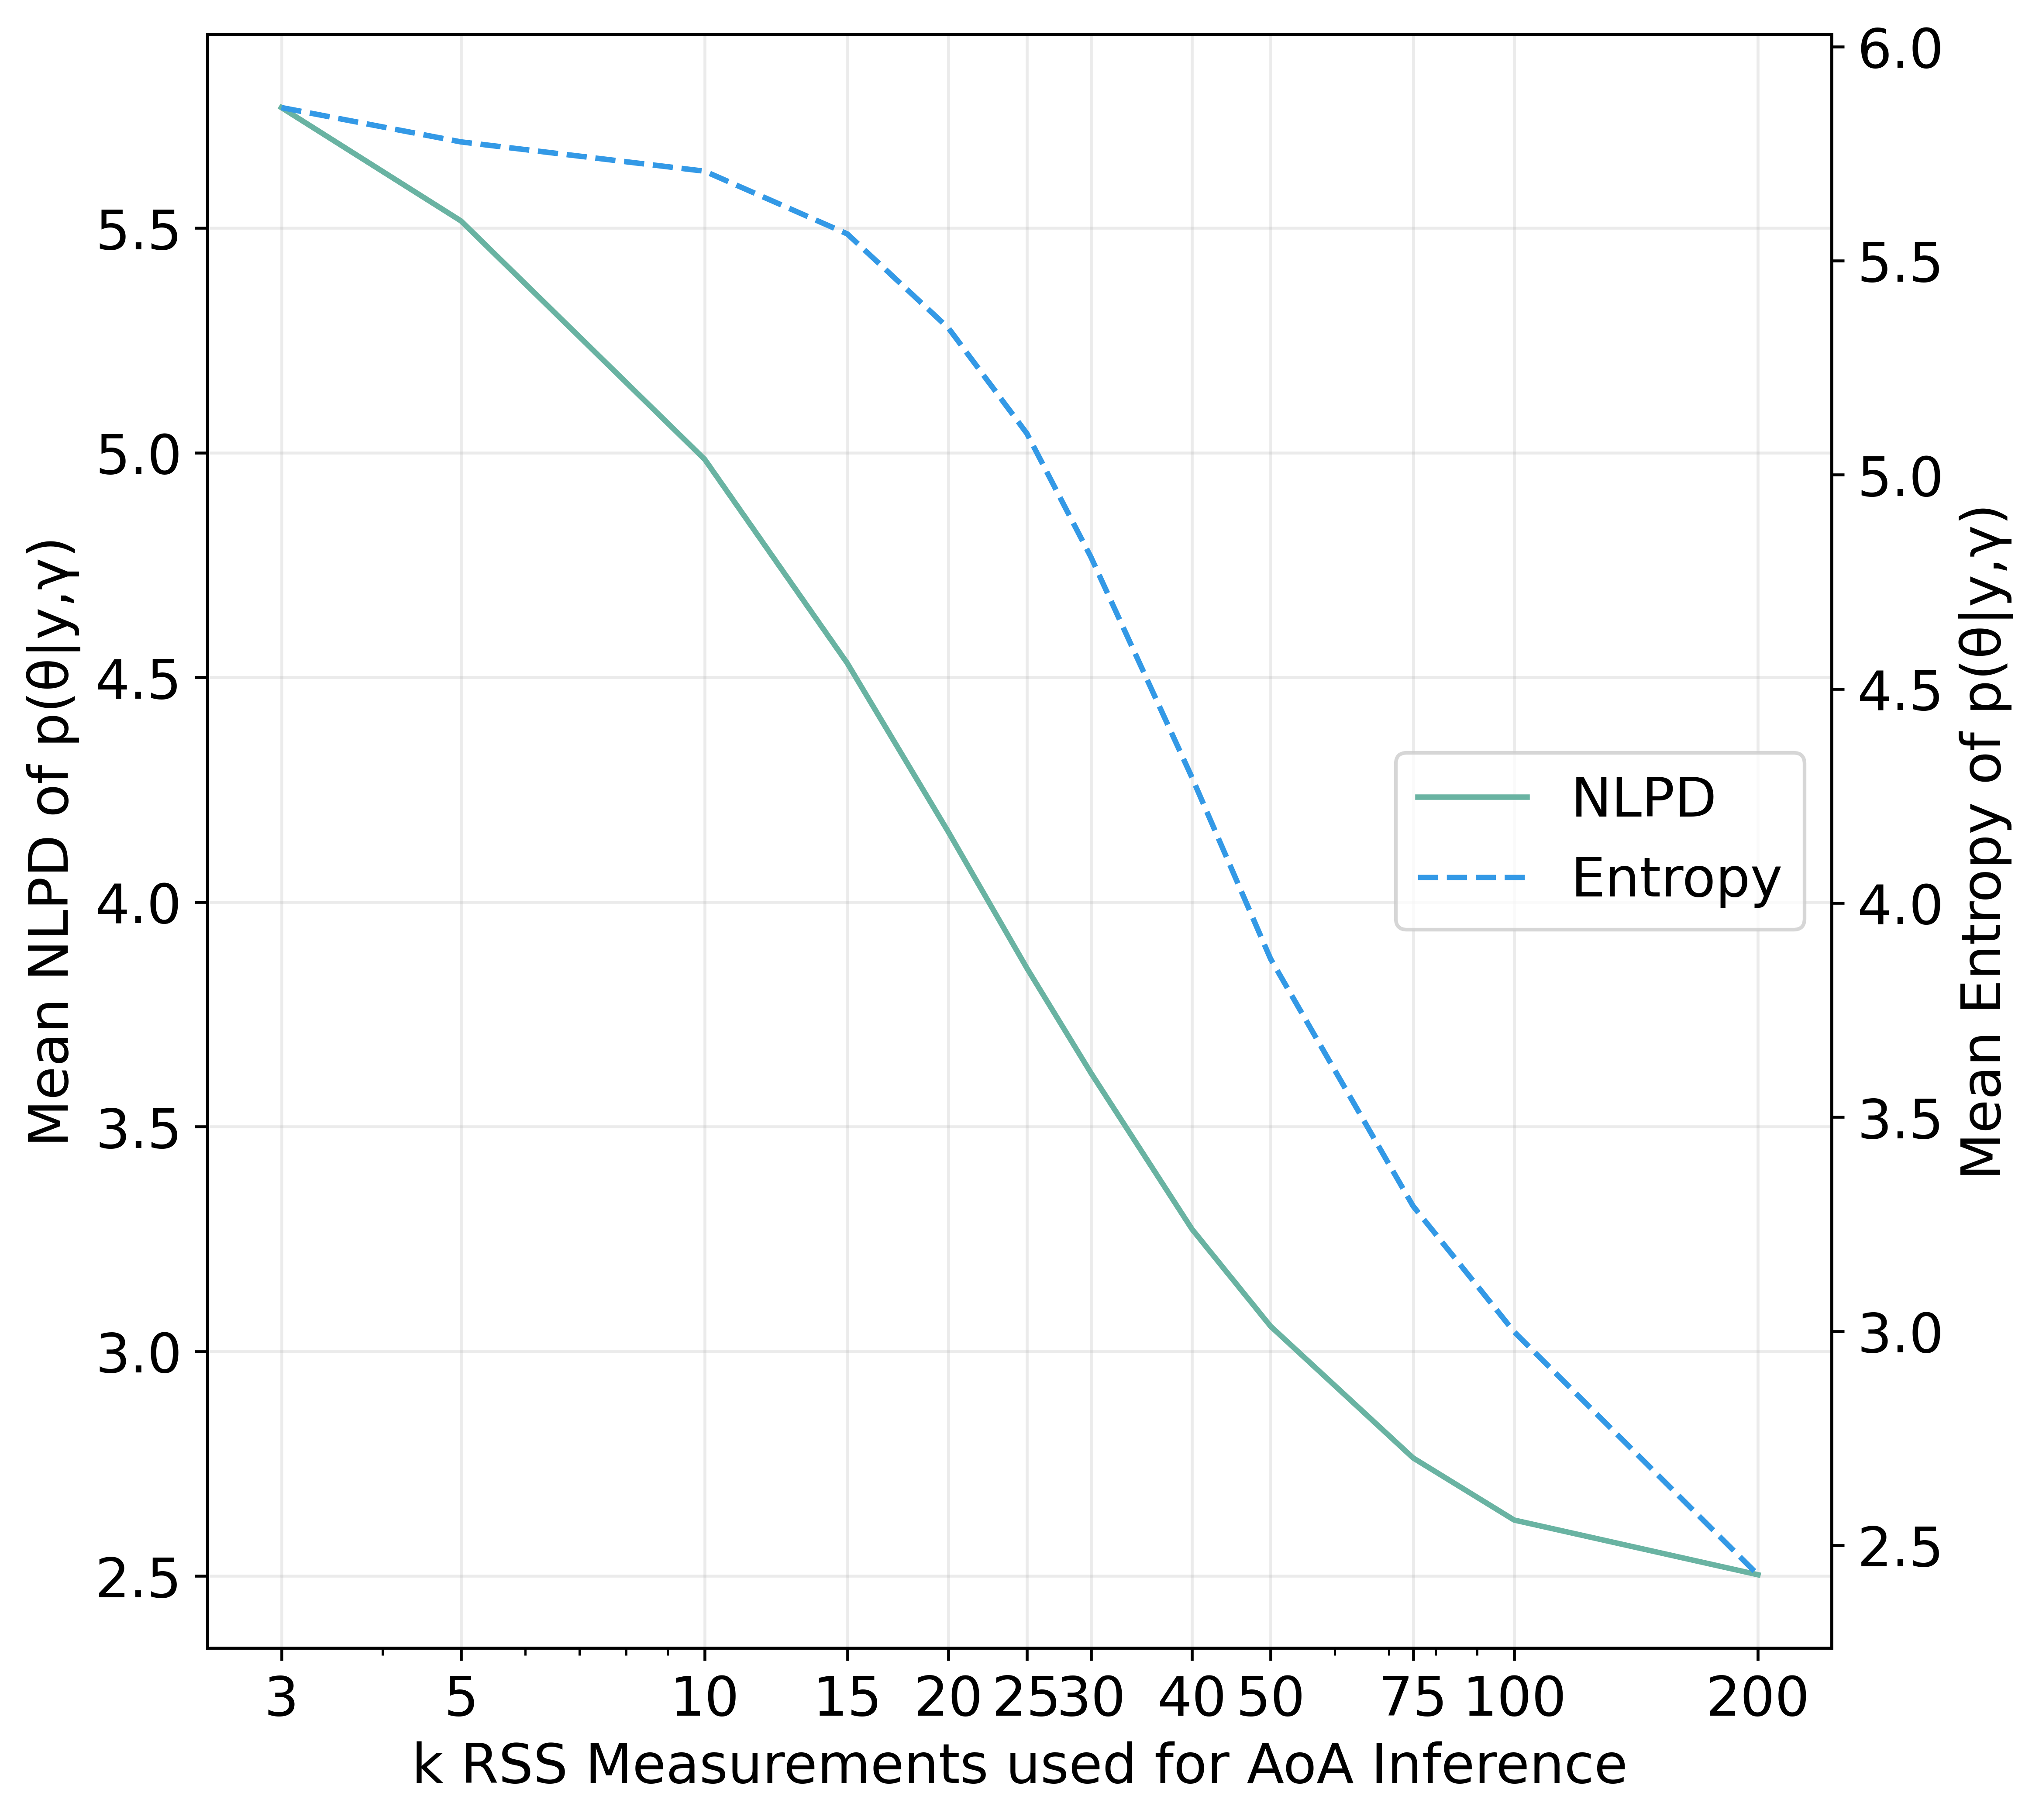

In [48]:
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 15}

mpl.rc('font', **font)
COLOUR_ANGLE = "#69b3a2"
COLOUR_VAR = "#3399e6"

fig, ax1 = plt.subplots(figsize=(8, 8), dpi = 600)
ax2 = ax1.twinx()

ax1.plot(k,accuracies, color=COLOUR_ANGLE, label = "NLPD")
#ax1.fill_between([(PACKET_ALLOWANCE/x) for x in k], [np.mean(x[0]) + np.std(x[0])*1.96 for x in results], [np.mean(x[0]) - np.std(x[0])*1.96 for x in results], color=COLOUR_PATH,alpha=0.2,label = "Path Reconstruction")

ax2.plot(k, variances, '--', color=COLOUR_VAR,label = "Entropy")

ax1.set_xlabel("k RSS Measurements used for AoA Inference")

ax1.set_ylabel("Mean NLPD of p(θ|y,γ)")
ax2.set_ylabel("Mean Entropy of p(θ|y,γ)")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

plt.xscale("log")
plt.xticks(k, [str(t) for t in k], fontsize=5)
ax1.grid(alpha=0.25)
plt.savefig("nlpd.png")



# Rejection Sampling Attempt 2.0

In [85]:
# TODO:
# - Make it work with angles
# - Make it faster ✅
# - Make it an object and clean it up
# - Output clockwise instead of counter clockwise ✅
# - Dynamically change the rejection threshold ✅
# - Update random index sampling in signals.py ✅
# - Better choice of angle in burst to use as prediction ✅

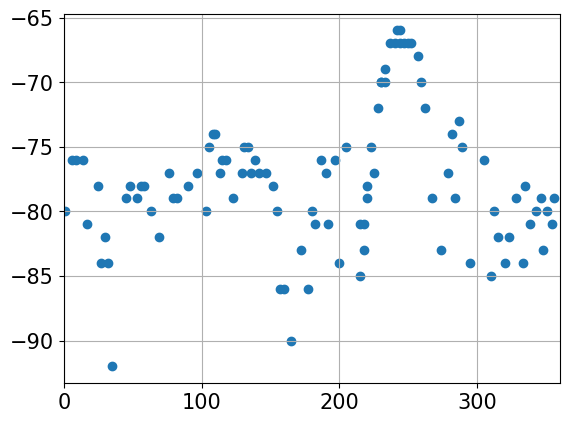

In [86]:
burstIndex = 10
nSamps = 100
# THIS PLOT SHOWS PACKETS AS THEY ARE, NOT ADJUSTED FOR BEING COUNTERCLOCKWISE
burst, time = testsigs.parseBursts(burstInterval=0, offset = 0)
currentBurst = randomSampleFromBurstDict(burst[burstIndex], nSamps)
plt.scatter(np.rad2deg(currentBurst['angles']), currentBurst['rssis'])
plt.xlim(0,360)
plt.grid()

In [87]:
trainingData = Signals("../bluetooth_experiments/no rf amp experiments/noamploc2long.log",'d',angleOffset = 38).data
burstTimes = currentBurst['times'] - np.min(currentBurst['times'])
print(currentBurst['angles'])
print(burstTimes)

Standardising angles and times (shifting by 38.00 degrees)
[4.01 4.07 4.14 4.19 4.22 4.26 4.26 4.31 4.36 4.4  4.49 4.52 4.57 4.66
 4.78 4.87 4.92 4.96 5.01 5.04 5.15 5.32 5.41 5.45 5.5  5.59 5.64 5.72
 5.81 5.85 5.9  5.99 6.04 6.07 6.13 6.18 6.21 0.02 0.1  0.16 0.24 0.3
 0.44 0.47 0.52 0.56 0.61 0.79 0.84 0.93 0.98 1.01 1.1  1.2  1.33 1.38
 1.43 1.57 1.69 1.8  1.83 1.88 1.92 1.97 2.01 2.06 2.15 2.25 2.29 2.34
 2.37 2.43 2.48 2.57 2.65 2.71 2.74 2.79 2.88 3.   3.09 3.14 3.18 3.26
 3.32 3.35 3.44 3.49 3.58 3.75 3.8  3.84 3.89 3.98 4.07 3.75 3.8  3.84
 3.93 4.01]
[  80.   93.  119.  133.  146.  159.  159.  172.  186.  199.  226.  238.
  252.  278.  318.  345.  357.  371.  384.  397.  424.  477.  504.  517.
  530.  556.  570.  596.  623.  636.  650.  676.  690.  703.  716.  730.
  743.  769.  796.  809.  836.  849.  889.  903.  916.  929.  943.  996.
 1009. 1036. 1049. 1063. 1089. 1116. 1156. 1170. 1183. 1223. 1263. 1290.
 1304. 1316. 1330. 1344. 1356. 1370. 1397. 1424. 1437. 1451. 1464. 1

In [88]:
# Function to get sample from the training data
def GetSample(data, time):
    data_times = data[:, -1]
    times = burstTimes + time

    idxs = np.searchsorted(data_times, times, side='left')

    idxs = np.clip(idxs, 1, len(data_times) - 1)

    left_idx = idxs - 1
    right_idx = idxs

    left_dist = np.abs(times - data_times[left_idx])
    right_dist = np.abs(data_times[right_idx] - times)

    # Trying to match argmin behaviour
    choose_left = left_dist <= right_dist
    idxs = np.where(choose_left, left_idx, right_idx)

    sigs = data[idxs, 0]
    signaldiffs = sigs[:-1] - sigs[-1]

    # Use middle most packet for angle prediction
    return signaldiffs, data[idxs, 2][-1], sigs


# Function to transform burst into a sample to compare with the training record
def GetSampleFromBurst(burst, time):
    times = np.array(burst['times'])
    data = []
    for i in range(len(burst['rssis'])):
        data.append([burst['rssis'][i], burst['angles'][i], burst['times'][i]])
    data = np.array(data)
    idxs = np.argmin(np.abs(data[:, -1:] - times[None, :]), 0)
    sigs = data[idxs, 0]
    signaldiffs = sigs[:-1] - sigs[-1]
    print(data[idxs, 1])
    # Use middle most packet for angle prediction
    return signaldiffs , data[idxs, 1][-1], data[idxs, 0]

In [89]:
rejectionTableStep = 50

def createRejectionTable(trainingdata):
    mint = np.min(trainingdata[:, -1])
    maxt = np.max(trainingdata[:, -1])

    ts = np.arange(mint + 100e3, maxt, rejectionTableStep)
    n_rows = len(ts)

    # Call once to infer sizes
    signalstrengths, angle, _ = GetSample(trainingdata, ts[0])
    n_sig = len(signalstrengths)

    record = np.empty((n_rows, 1 + n_sig + 1), dtype=float)

    for i, t in enumerate(ts):
        signalstrengths, angle, _ = GetSample(trainingdata, t)
        record[i, 0] = t
        record[i, 1:1+n_sig] = signalstrengths
        record[i, -1] = angle

        if i % 1000 == 0:
            print(f"{int(t - mint)}ms out of {int(maxt - mint)}ms")

    print(f"Rejection table built of {int(maxt - mint)}ms of antenna profile.")
    return record

In [90]:
table = createRejectionTable(trainingData)

100000ms out of 733482ms
150000ms out of 733482ms
200000ms out of 733482ms
250000ms out of 733482ms
300000ms out of 733482ms
350000ms out of 733482ms
400000ms out of 733482ms
450000ms out of 733482ms
500000ms out of 733482ms
550000ms out of 733482ms
600000ms out of 733482ms
650000ms out of 733482ms
700000ms out of 733482ms
Rejection table built of 733482ms of antenna profile.


In [91]:
ss, ang, rawss = GetSampleFromBurst(currentBurst, 0)

[4.01 4.07 4.14 4.19 4.22 4.26 4.26 4.31 4.36 4.4  4.49 4.52 4.57 4.66
 4.78 4.87 4.92 4.96 5.01 5.04 5.15 5.32 5.41 5.45 5.5  5.59 5.64 5.72
 5.81 5.85 5.9  5.99 6.04 6.07 6.13 6.18 6.21 0.02 0.1  0.16 0.24 0.3
 0.44 0.47 0.52 0.56 0.61 0.79 0.84 0.93 0.98 1.01 1.1  1.2  1.33 1.38
 1.43 1.57 1.69 1.8  1.83 1.88 1.92 1.97 2.01 2.06 2.15 2.25 2.29 2.34
 2.37 2.43 2.48 2.57 2.65 2.71 2.74 2.79 2.88 3.   3.09 3.14 3.18 3.26
 3.32 3.35 3.44 3.49 3.58 3.75 3.8  3.84 3.89 3.98 4.07 3.75 3.8  3.84
 3.93 4.01]


In [92]:
# Keep increasing rejection threshold until we get at least 100 hits
rejectionThreshold = 6
mean_error = np.mean(np.abs(ss - table[:, 1:-1]), axis=1)
selectedRecords = mean_error < rejectionThreshold
predangle = table[selectedRecords, -1] 

Angular error: 13.05417195207636


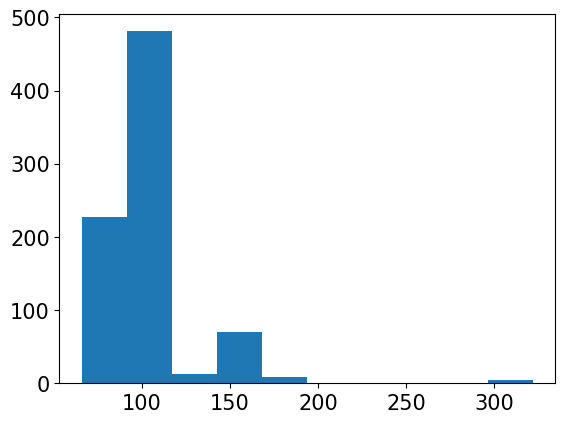

In [93]:
predangle -= (ang)
predangle[predangle < 0] += np.pi * 2
predangle[predangle > 2 * np.pi] -= np.pi * 2
#predangle = (-predangle) % (2*np.pi)
plt.hist(np.rad2deg(predangle))

print("Angular error: " + str(angularDistance(np.rad2deg(circmean(predangle)), groundTruthAngle)))

# Test with angleinference.py

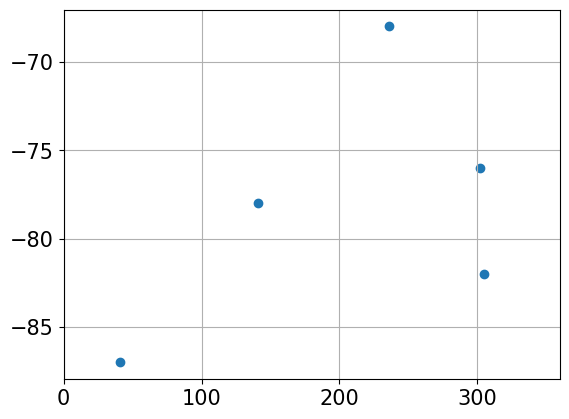

In [26]:
burstIndex = 12
nSamps = 5
# THIS PLOT SHOWS PACKETS AS THEY ARE, NOT ADJUSTED FOR BEING COUNTERCLOCKWISE
burst, time = testsigs.parseBursts(burstInterval=0, offset = 0)
currentBurst = randomSampleFromBurstDict(burst[burstIndex], nSamps)
plt.scatter(np.rad2deg(currentBurst['angles']), currentBurst['rssis'])
plt.xlim(0,360)
plt.grid()

Standardising angles and times (shifting by 38.00 degrees)


123.65270805159884

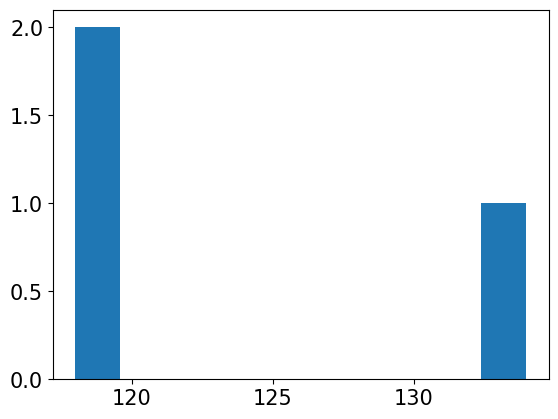

In [28]:
rejectionSamp = AnglesUseRejectionSampling(rejectionTableStep = 100)
rejectionSamp.infer(currentBurst, rejectionThreshold = 5)

# Test with path data?

In [29]:
pathIndex = 2
nSamps = 100 # Max number of samples to use per burst for path reconstruction
             # (2 second bursts, how many samples within that burst)
paths = [["../bluetooth_experiments/March 26 2025 Field Trial/complexpath7/complexpath7.log", "../bluetooth_experiments/March 26 2025 Field Trial/complexpath7/2025-03-26_12_05_30_my_iOS_device.csv", 8,26],
         ["../bluetooth_experiments/March 26 2025 Field Trial/complexpath8/complexpath8.log","../bluetooth_experiments/March 26 2025 Field Trial/complexpath8/2025-03-26_12_09_13_my_iOS_device.csv",5,24],
         ["../bluetooth_experiments/March 26 2025 Field Trial/complexpath9/complexpath9.log","../bluetooth_experiments/March 26 2025 Field Trial/complexpath9/2025-03-26_12_13_54_my_iOS_device.csv" ,5,28]]

In [30]:
testdata = Signals(paths[pathIndex][0],['e'],filetype='log',angleOffset=0)
GPSfilepath = paths[pathIndex][1]

# For evaluating the GPS path pointwise against the inferred path, we want to infer a path across the times that we've tracked with GPS
startingTime = paths[pathIndex][2]
endingTime = paths[pathIndex][3]

Standardising angles and times (shifting by 0.00 degrees)


Transmitter       Number of records
        e                 7515


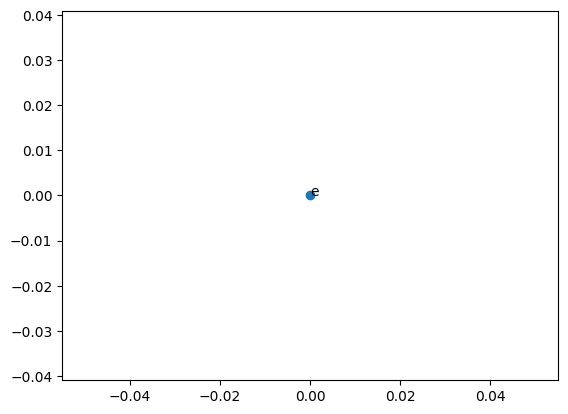

In [35]:
testdata.configureTransmitter('e',-167340,0,transmitterLat = 53.369204, transmitterLon = -1.449990)
# Normalise the transmitter locations around zero, in preparation for the observations
testdata.noramliseTransmitterLocs()
testdata.summarise(showNormalised = True)

Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degrees)
Standardising angles and times (shifting by 38.00 degree

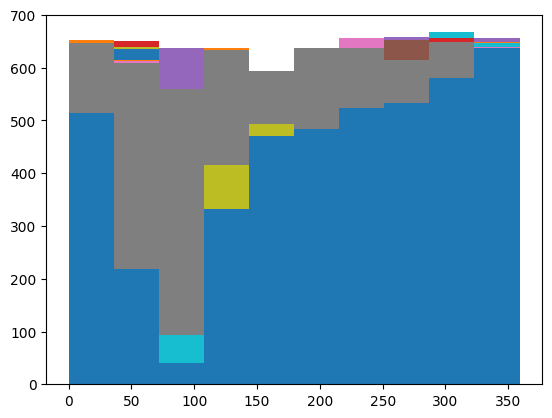

In [38]:
predictions = []
burst, time = testdata.parseBursts(burstInterval=0)
for b in range(len(burst)):
    currentBurst = testdata.subsampleBurst(burst[b], nSamps, 2000, method=samplingMethod)
    rejectionSamp = AnglesUseRejectionSampling(rejectionTableStep = 100)
    predictions.append(rejectionSamp.infer(currentBurst, rejectionThreshold = 14))

(array([38.,  6.,  4.,  6.,  8.,  0.,  0.,  5.,  8., 36.]),
 array([  6.76,  41.79,  76.82, 111.86, 146.89, 181.92, 216.95, 251.98,
        287.01, 322.04, 357.07]),
 <BarContainer object of 10 artists>)

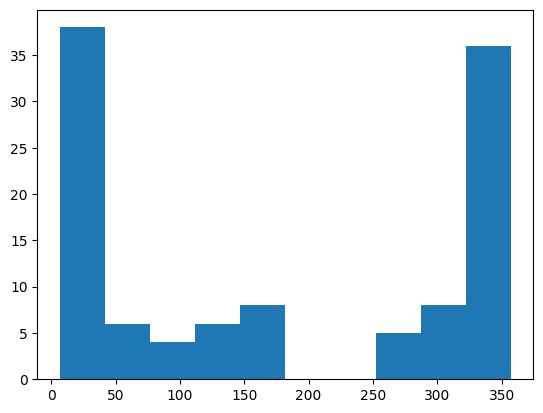

In [39]:
plt.hist(predictions)

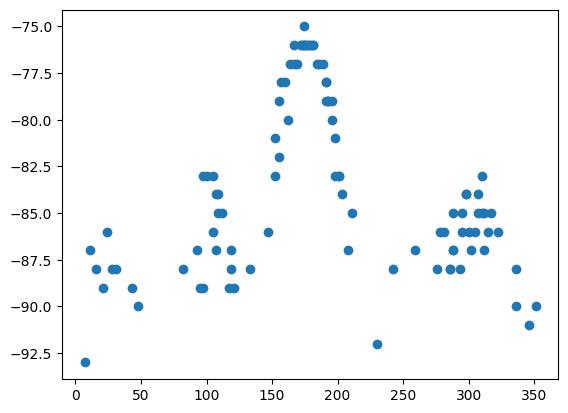

In [33]:
samplingMethod = "linspaceIdxs" # random, linspaceTimes, linspaceIdxs
b = 30
nSamps = 100
burst, time = testdata.parseBursts(burstInterval=0)
currentBurst = testdata.subsampleBurst(burst[b], nSamps, 2000, method=samplingMethod)
plt.scatter(np.rad2deg(currentBurst['angles']), currentBurst['rssis'])

Standardising angles and times (shifting by 38.00 degrees)


15.282806579763943

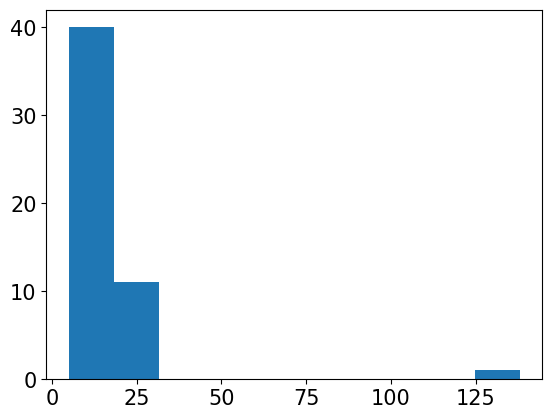

In [142]:
rejectionSamp = AnglesUseRejectionSampling(rejectionTableStep = 100)
rejectionSamp.infer(currentBurst, rejectionThreshold = 14)

Standardising angles and times (shifting by 38.00 degrees)


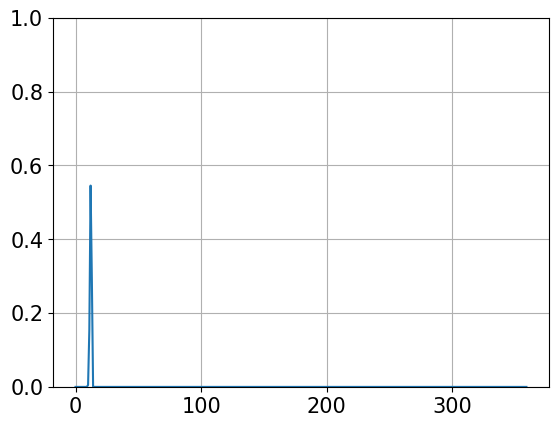

In [143]:
angles = AnglesUsePatternMeans(noisevar=3**2)

logps,_,_,_ = angles.infer(currentBurst['rssis'],currentBurst['angles'])
#logps = np.log(np.exp(logps)+1e-1000)
ps = normalise_logs_to_ps(logps)
plt.plot(np.linspace(0,359,360),ps)
#print(np.max(logps),np.max(ps),np.sum(ps))
        
plt.ylim([-0.001,1]) #1.1*np.max(ps)])
plt.grid()

In [61]:
test = np.zeros(360)

360